# Simple PhysioNet metrics

This notebook contains a simple set of metrics derived from data extracted from the PhysioNet database.

## Setup

In [73]:
import os

import matplotlib.pyplot as plt
import polars as pl

## Load data

Loading data for analysis, including:

- users
- projects
- historical data (pre-2020)

In [74]:
# path to datasets
base_path = os.path.join("..", "data", "physionet")

# iterate folder
for file in os.listdir(base_path):
    print(file)

users.csv
projects.csv


In [75]:
users = pl.read_csv(os.path.join(base_path, "users.csv"))
projects = pl.read_csv(os.path.join(base_path, "projects.csv"))

In [76]:
users.head()

user_id,username,join_date,last_login,registration_ip,is_active_user,primary_email,all_emails,first_names,last_name,full_name,affiliation,location,website,orcid_id,credentialing_status,credentialing_organization_name,credentialing_job_title,credentialing_city,credentialing_state_or_province,credentialing_country,credentialing_webpage,credentialing_reference_name,credentialing_reference_email,credentialing_reference_org,credentialing_reference_response,credentialing_research_summary
i64,str,str,str,str,bool,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str
2,"""ftorres""","""2019-01-11""","""2024-05-30 23:51:55.929525+00:…","""""",true,"""ftf.dummy@gmail.com""","""ftorres@physionet.org, ftf.dum…","""Felipe III""","""Torres Fábregas""","""Felipe III Torres Fábregas""","""MIT""","""""","""""","""""","""Credentialed""","""MIT""","""TEST""","""TEST""","""TEST""","""US""","""""","""TEST""","""felipe.torres.cs@gmail.com""","""""","""""","""TEST"""
6,"""tompollard""","""2019-02-19""","""2024-08-01 15:22:27.844114+00:…","""""",true,"""tpollard@mit.edu""","""tpollard@mit.edu, tompollardx@…","""Tom""","""Pollard""","""Tom Pollard""","""Massachusetts Institute of Tec…","""""","""""","""0000-0002-5676-7898""","""Credentialed""","""Massachusetts Institute of Tec…","""Research Scientist""","""Somerville""","""MA""","""US""","""""","""Tom Pollard""","""tpollard@mit.edu""","""""","""Me.""","""Laboratory for Computational P…"
8,"""benjamin""","""2019-02-21""","""2024-08-06 20:16:01.888720+00:…","""""",true,"""bmoody@mit.edu""","""bmoody@mit.edu, benjaminmoody+…","""Benjamin""","""Moody""","""Benjamin Moody""","""Massachusetts Institute of Tec…","""Cambridge, MA, USA""","""""","""""","""No application found""","""""","""""","""""","""""","""""","""""","""""","""""","""""","""""",""""""
10,"""alistairewj""","""2019-02-21""","""2024-08-06 11:30:44.084928+00:…","""""",true,"""alistairewj@gmail.com""","""alistairewj@gmail.com, aewj@mi…","""Alistair""","""Johnson""","""Alistair Johnson""","""Massachusetts Institute of Tec…","""Cambridge, MA, USA""","""https://alistairewj.github.io""","""""","""Credentialed""","""Massachusetts Institute of Tec…","""Research Scientist""","""Cambridge""","""MA""","""US""","""https://alistairewj.github.io""","""Tianshu Feng""","""fengpenny@gmail.com""","""""","""""",""""""
11,"""jueurousseau""","""2019-02-22""","""2024-05-09 10:46:11.837600+00:…","""""",true,"""euma@mit.edu""","""euma@mit.edu, jueurousseau@gma…","""Julian Euma""","""Ishii-Rousseau""","""Julian Euma Ishii-Rousseau""","""""","""""","""""","""""","""Credentialed""","""""","""""","""""","""""","""""","""""","""""","""""","""""","""""",""""""


In [77]:
projects.head()

project_id,core_project_id,project_slug,version,publish_date,has_other_versions,version_order,is_latest_version,project_doi,core_project_doi,full_description,submitting_author_id,title,abstract,background,methods,content_description,usage_notes,installation,acknowledgements,conflicts_of_interest,release_notes,short_description,access_policy,license,data_use_agreement,project_home_page,ethics_statement,corresponding_author_id,author_ids,associated_paper,associated_paper_url
i64,str,str,str,str,bool,i64,bool,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,i64,str,str,str,str,str,str,str,str
292,"""cbf2f243-9315-40e4-8f9f-a1dd61…","""bhi-2018-challenge""","""1.0""","""2018-02-05 17:12:37.990720+00:…",false,0,true,"""10.13026/v1jk-ax96""","""10.13026/5bhj-nf42""","""""","""22""","""2018 IEEE BHI and BSN Data Cha…","""In collaboration with the IEEE…","""The 2018 IEEE BHI & BSN Data C…","""Participating teams have one m…","""Participants will use the MIMI…","""At least one member of a team …","""""","""The organizers would like to t…","""No conflicts of interest.""","""""","""A challenge to explore real cl…",0,"""MIT License""","""""","""https://bhi-bsn.embs.org/2018/""","""""","""22""","""22, 21, 23""","""""",""""""
170,"""bb5406a7-92a3-4e05-b5e0-0b08ee…","""adfecgdb""","""1.0.0""","""2012-08-09 04:00:00+00:00""",false,0,true,"""10.13026/C2RP4B""","""""","""### Abstract The research mat…","""""","""Abdominal and Direct Fetal ECG…","""The research material included…","""""","""""","""""","""""","""""","""""","""""","""""","""Multichannel fetal electrocard…",0,"""Open Data Commons Attribution …","""""","""""","""""","""""","""""","""Jezewski J, Matonia A, Kupka T…","""http://www.degruyter.com/view/…"
540,"""3662aefa-49a8-4cf9-8a97-1968ff…","""brazilian-ophthalmological""","""1.0.0""","""2023-03-08 21:48:48.436632+00:…",false,0,true,"""10.13026/xcxw-8198""","""10.13026/z9zv-g542""","""""","""1473""","""A Brazilian Multilabel Ophthal…","""The Brazilian Multilabel Ophth…","""In ophthalmology, ancillary im…","""This project was approved by t…","""This dataset enables computer …","""This is the first Brazilian op…","""""","""The creation of this dataset p…","""The authors declare no conflic…","""We plan to include self-declar…","""This is the first Brazilian Mu…",2,"""PhysioNet Credentialed Health …","""PhysioNet Credentialed Health …","""""","""This project was approved by t…","""1473""","""1473, 1469, 1470, 1474, 1468, …","""""",""""""
260,"""3471633f-e83e-4772-beaf-c67ea5…","""rcvsim""","""1.0.0""","""2001-09-19 04:00:00+00:00""",false,0,true,"""""","""""","""### Abstract We introduce her…","""""","""A Cardiovascular Simulator for…","""We introduce here the Research…","""""","""""","""""","""""","""""","""""","""""","""""","""""",0,"""Open Data Commons Attribution …","""""","""""","""""","""""","""""","""""",""""""
624,"""dc177b77-cf57-4f31-982f-c902ec…","""perg-ioba-dataset""","""1.0.0""","""2024-01-19 22:00:11.658670+00:…",false,0,true,"""10.13026/d24m-w054""","""10.13026/2t6a-xq52""","""""","""1993""","""A Comprehensive Dataset of Pat…","""The pattern electroretinogram …","""The pattern electroretinogram …","""#### Participants The dataset…","""The dataset comprises a total …","""The comprehensive and high-qua…","""""","""This work was supported by a b…","""The authors have no conflicts …","""""","""336 CSV records with 1354 PERG…",0,"""Open Data Commons Attribution …","""""","""""","""The data were collected during…","""1993""","""1993, 1996, 1995, 1997, 1994""","""""",""""""


## Metrics

Extract simple metrics from the user and project data.

In [78]:
# Convert date columns to date type
users = users.with_columns(pl.col("join_date").str.strptime(pl.Date, "%Y-%m-%d"))
projects = projects.with_columns(pl.col("publish_date").str.to_datetime("%Y-%m-%d %H:%M:%S%.f%z", strict=False))

In [79]:
# Number of new users per year
users_per_year = users.with_columns(
    pl.col("join_date").dt.year().alias("year")
).group_by("year").agg(
    pl.count("user_id").alias("count")
)
users_per_year

year,count
i32,u32
2019,6773
2022,21289
2023,29237
2020,15461
2021,18536
2024,20617


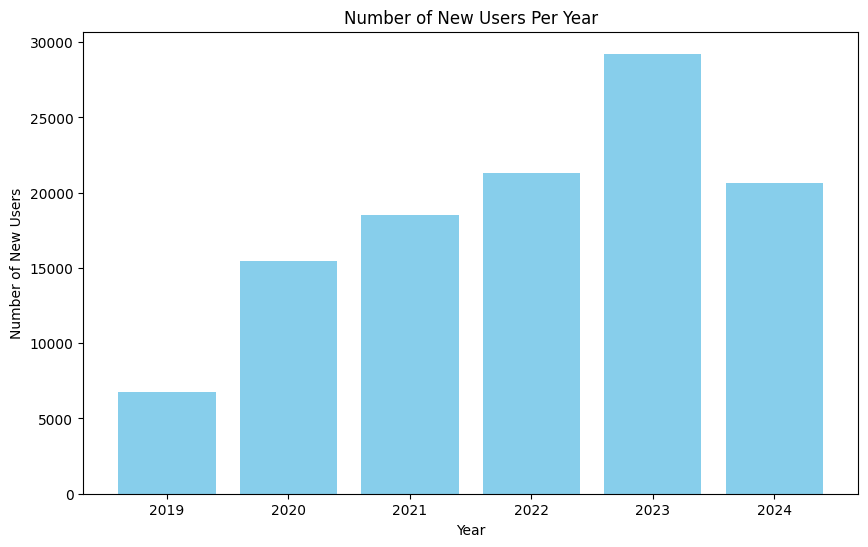

In [80]:
# Plot number of new users per year
plt.figure(figsize=(10, 6))
plt.bar(users_per_year["year"].to_list(), users_per_year["count"].to_list(), color='skyblue')
plt.xlabel("Year")
plt.ylabel("Number of New Users")
plt.title("Number of New Users Per Year")
plt.xticks(users_per_year["year"].to_list())
plt.show()

In [81]:
# Number of new published projects per year
projects_per_year = projects.with_columns(
    pl.col("publish_date").dt.year().alias("year")
).group_by("year").agg(
    pl.count("project_id").alias("count")
)
projects_per_year

year,count
i32,u32
2010,3
2016,16
2001,8
2000,11
2006,2
…,…
2017,16
2023,86
2018,18


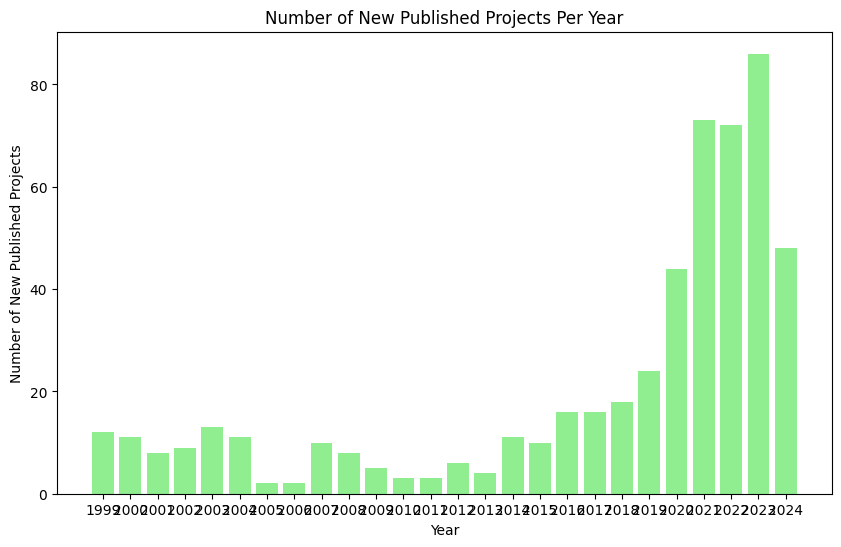

In [82]:
# Plot number of new published projects per year
plt.figure(figsize=(10, 6))
plt.bar(projects_per_year["year"].to_list(), projects_per_year["count"].to_list(), color='lightgreen')
plt.xlabel("Year")
plt.ylabel("Number of New Published Projects")
plt.title("Number of New Published Projects Per Year")
plt.xticks(projects_per_year["year"].to_list())
plt.show()